In [1]:
# Python 3.10.11
# %pip install -r requirements.txt > /dev/null
from args import *
from utils import *

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

from torchmetrics import AUROC
from torch.utils.tensorboard import SummaryWriter


# 依赖导入
import pandas as pd


/root/miniforge3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
balance = True


# 导入label数据
label_df = pd.read_csv(sample_labels_file_path, index_col=0)

# 裁减样本数量，使得 0 - 1 样本数量一致
df_0 = label_df[label_df['label'] == 0]
df_1 = label_df[label_df['label'] == 1]
min_len = min(len(df_0), len(df_1))
new_df = pd.concat([df_0[:min_len], df_1[:min_len]], axis=0)

sample_key_list = label_df.index.to_list()
if balance:
    sample_key_list = new_df.index.to_list() # 均衡数据

print(f"label 样本数量: {len(sample_key_list)}")

# TODO(241225) 导入gene数据
# 根据 sample_key_list 为基准, 若模态数据中不存在 sample_key 则填充新数据
origin_gene_array = load_gene_data_by_sample_key(sample_key_list).values
origin_cnv_array = load_cnv_data_by_sample_key(sample_key_list).values

origin_wsi_array = load_wsi_data_by_sample_key(sample_key_list)
origin_report_array = load_report_data_by_sample_key(sample_key_list)

label 样本数量: 152
{'TCGA-2W-A8YY-01': array([[-3.84459734e-01, -5.02654731e-01,  5.52053750e-01,
        -2.41826713e-01, -2.29795024e-01,  3.96330506e-02,
        -3.32728982e-01,  2.63716191e-01,  4.11511883e-02,
        -4.36652824e-03,  1.27996206e-01, -3.83492202e-01,
        -3.36197346e-01,  2.62911469e-01,  5.57049215e-01,
        -1.78931758e-01,  8.73637795e-01,  6.42181635e-02,
        -2.58307427e-01,  5.63099384e-02,  1.20530665e-01,
         3.53228539e-01,  2.15325773e-01, -2.08414167e-01,
        -3.41128170e-01,  2.43983492e-01, -4.72069293e-01,
        -1.23009801e-01,  2.24310979e-01,  2.46804073e-01,
        -2.94596225e-01,  3.12332988e-01,  2.39295661e-01,
        -2.03909755e-01,  2.67520875e-01,  1.63651466e-01,
         3.57053697e-01,  2.39336759e-01,  1.95658043e-01,
        -1.88812725e-02, -4.14929807e-01, -5.40982664e-01,
        -2.94966936e-01, -3.98663193e-01,  2.48205453e-01,
         1.24468520e-01,  7.65772521e-01, -1.30411744e-01,
         2.66814053e

In [4]:
def get_mode(mode_name, column_len=1_000_000):

    global origin_gene_array, origin_cnv_array, origin_wsi_array, origin_report_array

    mode_list = []

    for key in mode_name:
        
        if key == "g":
            mode = np.copy(origin_gene_array)
        elif key == "c":
            mode = np.copy(origin_cnv_array)
        elif key == "w":
            mode = np.copy(origin_wsi_array)
        elif key == "r":
            mode = np.copy(origin_report_array)
        mode_list.append(mode[:, :column_len])
    return tuple(mode_list)


In [5]:
mode_name = "gcwr"

gene_array, cnv_array, wsi_array, report_array = get_mode(mode_name)

In [6]:
gene_array.shape, cnv_array.shape, wsi_array.shape, report_array.shape

((152, 2340), (152, 2340), (152, 2048), (152, 768))

In [7]:
label_array = label_df.values
if balance:
    label_array = new_df.values # 均衡数据

_, gene_dim = gene_array.shape
_, cnv_dim = cnv_array.shape
_, wsi_dim = wsi_array.shape
_, report_dim = report_array.shape
_, label_dim = label_array.shape

print(f"""
gene 数据维度:   {gene_dim}
cnv 数据维度:    {cnv_dim}
wsi 数据维度:    {wsi_dim}
report 数据维度: {report_dim}
""")

batch_size = 32

all_dataset = MultiOmicsDataset(gene_array, cnv_array, report_array, wsi_array, label_array)

# 假设 all_dataset 是一个 Dataset 对象
train_len = int(len(all_dataset) * 0.8)  # 80% 的数据用作训练集
test_len = len(all_dataset) - train_len  # 剩余的数据用作验证集

# 使用 random_split 分割数据集
train_val_dataset, test_dataset = random_split(all_dataset, [train_len, test_len])

train_loader = DataLoader(all_dataset, batch_size=batch_size, shuffle=True, num_workers=3, drop_last=False)
val_loader = DataLoader(train_val_dataset, batch_size=batch_size, shuffle=False, num_workers=3, drop_last=False)


gene 数据维度:   2340
cnv 数据维度:    2340
wsi 数据维度:    2048
report 数据维度: 768



In [8]:
### 分割线

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# 构造含交叉注意力机制的Transformer
class TransformerEncoderLayerWithCrossAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1, dim_feedforward=2048,):
        super(TransformerEncoderLayerWithCrossAttention, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout)

        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, src, src_mask=None):

                # 自注意力机制
        src2 = self.self_attn(src, src, src, attn_mask=src_mask)[0]
        src = src + self.dropout1(src2)
        src = self.norm1(src)

        # 将输入序列平均拆分为4等分
        seq_len = src.size(1)
        seg_len = seq_len // 4
        seg1 = src[:, :seg_len, :]
        seg2 = src[:, seg_len:2*seg_len, :]
        seg3 = src[:, 2*seg_len:3*seg_len, :]
        seg4 = src[:, 3*seg_len:, :]

        # 交叉注意力机制
        seg1_cross, _ = self.cross_attn(seg1, seg2, seg2)
        seg2_cross, _ = self.cross_attn(seg2, seg3, seg3)
        seg3_cross, _ = self.cross_attn(seg3, seg4, seg4)
        seg4_cross, _ = self.cross_attn(seg4, seg1, seg1)

        # 合并交叉注意力结果
        src_cross = torch.cat([seg1_cross, seg2_cross, seg3_cross, seg4_cross], dim=1)
        src = src + self.dropout2(src_cross)
        src = self.norm2(src)

        # 线性层和残差连接
        src2 = self.linear2(self.dropout(F.relu(self.linear1(src))))
        src = src + self.dropout3(src2)
        src = self.norm3(src)

        return src

In [10]:
class TransformerEncoderWithCrossAttention(nn.Module):
    def __init__(self, encoder_layer, num_layers, norm=None):
        super(TransformerEncoderWithCrossAttention, self).__init__()
        self.layers = nn.ModuleList([encoder_layer for _ in range(num_layers)])
        self.num_layers = num_layers
        self.norm = norm

    def forward(self, src, mask=None):
        output = src

        for layer in self.layers:
            output = layer(output, src_mask=mask)

        if self.norm is not None:
            output = self.norm(output)

        return output

# 定义模型结构
class MultiOmicsModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(MultiOmicsModel, self).__init__()

        # 分割线
        global gene_dim, cnv_dim, report_dim, wsi_dim, label_dim

        same_all_feature_dim = 128
        self.shared_hidden_gene_cnv = nn.Linear(gene_dim + cnv_dim, gene_dim)
        self.hidden_gene = nn.Sequential(nn.Linear(gene_dim, same_all_feature_dim))
        self.hidden_cnv = nn.Sequential(nn.Linear(gene_dim, same_all_feature_dim))

        self.fc_report = nn.Linear(report_dim, same_all_feature_dim)
        self.fc_wsi = nn.Linear(wsi_dim, same_all_feature_dim)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_prob)

        

        # 创建一个带有交叉注意力的Transformer编码器层
        # nn.MultiheadAttention(d_model, nhead, dropout=dropout) 
        d_model, nhead, dropout = same_all_feature_dim, 1, 0.1
        dim_feedforward = 32
        num_layers = 1
        encoder_layer = TransformerEncoderLayerWithCrossAttention(d_model, nhead, dropout, dim_feedforward)
        # 创建一个带有交叉注意力的Transformer编码器
        self.encoder = TransformerEncoderWithCrossAttention(encoder_layer, num_layers)

        self.flatten = nn.Flatten(start_dim=1)

        # 输出层
        self.lin = nn.Linear(same_all_feature_dim * 4, 1)


    def forward(self, gene_tensor, cnv_tensor, report_tensor, wsi_tensor):

        gene_cnv_feature = torch.concat([gene_tensor, cnv_tensor], dim=1)
        gene_cnv_feature = self.relu(self.shared_hidden_gene_cnv(gene_cnv_feature))
        gene_cnv_feature = self.dropout(gene_cnv_feature)

        report_feature = self.fc_report(report_tensor)
        report_feature = self.relu(report_feature)

        wsi_feature = self.fc_wsi(wsi_tensor)
        wsi_feature = self.relu(wsi_feature)

        gene_feature = self.hidden_gene(gene_cnv_feature)
        gene_feature = self.relu(gene_feature)

        cnv_feature = self.hidden_cnv(gene_cnv_feature)
        cnv_feature = self.relu(cnv_feature)

        all_feature = torch.stack([gene_feature, cnv_feature, report_feature, wsi_feature])
        all_feature = self.dropout(all_feature)

        # all_feature = all_feature.permute(1, 0, 2)
        # all_feature = self.flatten(all_feature)
        
        # out = self.lin(all_feature)
        # return out

        """
        start:  torch.Size([4, 32, 64])
        before enccode:  torch.Size([32, 4, 64])
        after enccode:  torch.Size([32, 4, 64])
        end:  torch.Size([4, 32, 64])
        """
        all_feature = all_feature.permute(1,0,2)
        all_feature = self.encoder(all_feature)

        all_feature = all_feature.permute(1, 0, 2)
        all_feature = self.relu(all_feature)

        all_feature = self.dropout(all_feature)

        all_feature = all_feature.permute(1, 0, 2)
        all_feature = self.flatten(all_feature)
        
        out = self.lin(all_feature)
        out = torch.sigmoid(out)
        return out

In [11]:
print(f"""
gene 数据维度:   {gene_dim}
cnv 数据维度:    {cnv_dim}
wsi 数据维度:    {wsi_dim}
report 数据维度: {report_dim}
""")

# model(expr, cnv, report, sis)

# learning_rate = 0.001
# criterion = nn.BCEWithLogitsLoss()
# optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 定义损失函数和优化器
criterion = nn.BCEWithLogitsLoss()  # 适用于二分类问题

# # tb001-0120-0826.tar.gz
# model = MultiOmicsModel(0.200).to(device) # 250120-0829
# optimizer = optim.Adam(model.parameters(), lr=0.00007705015) # 250120-0829

# # tb002-0120-0845.tar.gz
# model = MultiOmicsModel(0.2050).to(device) # 250120-0846
# optimizer = optim.Adam(model.parameters(), lr=0.00007205015) # 250120-0846

# # tb003-0120-0901.tar.gz
# model = MultiOmicsModel(0.2010).to(device) # 250120-0901
# optimizer = optim.Adam(model.parameters(), lr=0.00006805015) # 250120-0901
# num_epochs = 
# tb004-0120-0927.tar.gz
model = MultiOmicsModel(0.35).to(device) # 250120-0928
optimizer = optim.Adam(model.parameters(), lr=0.0001) # 250120-0928



gene 数据维度:   2340
cnv 数据维度:    2340
wsi 数据维度:    2048
report 数据维度: 768



In [12]:
from thop import profile

# 假设 model 是你的 PyTorch 模型实例
# input_tensor 是一个代表输入数据的张量，其形状应与模型的输入层匹配
gene_tensor, cnv_tensor = torch.randn(1, gene_array.shape[1]), torch.randn(1, cnv_array.shape[1])
report_tensor, wsi_tensor = torch.rand(1, report_array.shape[1]), torch.randn(1, wsi_array.shape[1])

gene_tensor = gene_tensor.to(device)
cnv_tensor = cnv_tensor.to(device)
report_tensor = report_tensor.to(device)
wsi_tensor = wsi_tensor.to(device)

# 计算 FLOPs
flops, params = profile(model, inputs=(gene_tensor,cnv_tensor,report_tensor,wsi_tensor,))
print(f'FLOPs: {flops}')
print(f'Parameters: {params}')

[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.normalization.LayerNorm'>.
FLOPs: 11950112.0
Parameters: 11923173.0


In [13]:

def get_model_roc_score(outputs, labels, threshold=0.5):
    """
    # 假设你有一个模型的输出和相应的真实标签
    # outputs 是模型的输出, 概率
    # labels 是真实的标签
    outputs = torch.tensor([[0.1], [0.8], [0.3], [0.6]])
    labels = torch.tensor([1, 0, 1, 0])
    """
    score_dict = {}
    
    predicted = (outputs >= threshold).int().view(-1)
    predicted = predicted.cpu().detach().numpy()

    if isinstance(outputs, torch.Tensor):
        outputs = outputs.cpu().detach().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().detach().numpy()

    # score_dict["outputs"] = outputs
    # score_dict["labels"] = labels

    score_dict["auc"] = 0
    score_dict["accuracy"] = 0
    score_dict["f1_score"] = 0
    score_dict["recall"] = 0
    score_dict["precision"] = 0
    score_dict["mcc"] = 0

    # 计算混淆矩阵并获取TN, FP, FN, TP的值
    tn, fp, fn, tp = confusion_matrix(labels, predicted).ravel()

    # 计算特异性
    specificity = tn / (tn + fp)
    score_dict["specificity"] = specificity
    # print(f"Specificity: {specificity:.2f}")  # 输出特异性值

    # 计算灵敏度
    sensitivity = tp / (tp + fn)
    score_dict["sensitivity"] = sensitivity
    # print(predicted)

    return score_dict

In [14]:
from sklearn.metrics import roc_auc_score

def show_score(score, can_print=False, tb_index=None):
    auc = score["auc"]
    accuracy = score["accuracy"]
    f1_score = score["f1_score"]
    recall = score["recall"]
    specificity = score["specificity"]
    precision = score["precision"]
    mcc = score["mcc"]
    if can_print:
        print("AUC:", auc)
        print("Accuracy:", accuracy)
        print("F1 Score:", score["f1_score"])
        print("Recall:", f1_score)
        print("Specificity:", recall)
        print("Precision:", precision)
        print("MCC:", mcc)
    if tb_index is None:
        return
    global writer
    # 将指标写入 TensorBoard
    writer.add_scalar('Metrics/AUC', score["auc"], tb_index)
    writer.add_scalar('Metrics/Accuracy', score["accuracy"], tb_index)
    writer.add_scalar('Metrics/F1_Score', score["f1_score"], tb_index)
    writer.add_scalar('Metrics/Recall', score["recall"], tb_index)
    writer.add_scalar('Metrics/Specificity', score["specificity"], tb_index)
    writer.add_scalar('Metrics/Precision', score["precision"], tb_index)
    writer.add_scalar('Metrics/MCC', score["mcc"], tb_index)

In [15]:
# 初始化用于存储输出的列表
roc_outputs = []
roc_labels = []

In [16]:
# 初始化TensorBoard SummaryWriter
writer = SummaryWriter(data_output_dir_path / f'runs/multi-model/{mode_name}')

num_epochs = 7
for epoch in range(num_epochs):

    correct = 0
    total = 0
    # 初始化变量来存储所有预测值和标签
    all_labels = []
    all_preds_prob = []

    model.train()
    # 导入 batch 数据
    for batch in train_loader:
        gene_tensor = batch["gene_tensor"].to(device)
        cnv_tensor = batch["cnv_tensor"].to(device)
        report_tensor = batch["report_tensor"].to(device)
        wsi_tensor = batch["wsi_tensor"].to(device)
        label_tensor = torch.squeeze(batch["label_tensor"]).to(torch.float32).to(device).view(-1, 1)
        # label_tensor = label_tensor.squeeze()
        # label_tensor = label_tensor.long()
        
        outputs = model(gene_tensor, cnv_tensor, report_tensor, wsi_tensor)

        optimizer.zero_grad()
        loss = criterion(outputs, label_tensor)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)  # 获取预测的类别
        total += label_tensor.size(0)
        correct += (preds == label_tensor).sum().item()

    print("training loss: ", loss.item())
    score = get_model_roc_score(outputs, label_tensor.view(-1))
    show_score(score, can_print=False, tb_index=epoch)
    # writer.add_scalar('training/training_loss', loss.item(), epoch)

    # 计算准确率
    accuracy = correct / total
    print(f"training Accuracy: ({accuracy})")
    # writer.add_scalar('training/train_accuracy', accuracy, epoch)

    # 记录训练损失和准确率到同一个图表的不同系列
    writer.add_scalars('loss', {
        'train': loss.item(),
    }, epoch)

    writer.add_scalars('accuracy', {
        'train': accuracy,
    }, epoch)


    correct = 0
    total = 0
    # 初始化变量来存储所有预测值和标签
    all_labels = []
    all_preds_prob = []

    # 在每个epoch结束时进行验证
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            gene_tensor = batch["gene_tensor"].to(device)
            cnv_tensor = batch["cnv_tensor"].to(device)
            report_tensor = batch["report_tensor"].to(device)
            wsi_tensor = batch["wsi_tensor"].to(device)
            label_tensor = torch.squeeze(batch["label_tensor"]).to(torch.float32).to(device).view(-1, 1)
            # label_tensor = label_tensor.squeeze()
            # label_tensor = label_tensor.long()

            outputs = model(gene_tensor, cnv_tensor, report_tensor, wsi_tensor)


            # 将输出和标签添加到对应的列表中
            roc_outputs.append(outputs.cpu())  # 将输出移回 CPU 并添加到列表
            roc_labels.append(label_tensor.cpu())  # 将标签移回 CPU 并添加到列表

            loss = criterion(outputs, label_tensor)

            # outputs = model(gene_tensor)
            _, preds = torch.max(outputs, 1)  # 获取预测的类别
            total += label_tensor.size(0)
            correct += (preds == label_tensor).sum().item()
            
            # 假设outputs是模型的输出，形状为[24, 2]
            # 我们只关心正类的概率，所以取第二列（索引为1）
            all_preds_prob.extend(torch.sigmoid(outputs)[:, -1].cpu().numpy())
            all_labels.extend(label_tensor.cpu().numpy())

    writer.add_scalars('loss', {
        'valid': loss.item(),
    }, epoch)

    # 计算准确率
    accuracy = correct / total
    print(f"Validation Accuracy: ({accuracy})")
    # writer.add_scalar('validation/validation_accuracy', accuracy, epoch)

    # 计算AUC
    auc = roc_auc_score(all_labels, all_preds_prob)
    print(f'AUC: {auc}')
    # writer.add_scalar('validation/validation_auc', auc, epoch)

    writer.add_scalars('accuracy', {
        'valid': accuracy,
    }, epoch)

    writer.add_scalars('auc', {
        'valid': auc,
    }, epoch)

writer.close()

# !scp -r /workspace/pyfaster/examples/model/data/output/runs adb6804e7b6df030ddab1a51a18e2ec7d2f9abad-woplfq@woplfq.ssh.cloudstudio.work:/tmp ;
# !rm -rf /workspace/pyfaster/examples/model/data/output/runs


training loss:  0.6785223484039307
training Accuracy: (15.526315789473685)
Validation Accuracy: (14.851239669421487)
AUC: 0.7055768179332969
training loss:  0.6716649532318115
training Accuracy: (15.578947368421053)
Validation Accuracy: (14.851239669421487)
AUC: 0.6979223619464188
training loss:  0.7086621522903442
training Accuracy: (15.157894736842104)
Validation Accuracy: (14.851239669421487)
AUC: 0.6845270639693821
training loss:  0.6730382442474365
training Accuracy: (15.368421052631579)
Validation Accuracy: (14.851239669421487)
AUC: 0.6905412793876435
training loss:  0.6698471307754517
training Accuracy: (15.421052631578947)
Validation Accuracy: (14.851239669421487)
AUC: 0.7025697102241661
training loss:  0.6905922293663025
training Accuracy: (15.368421052631579)
Validation Accuracy: (14.851239669421487)
AUC: 0.7110442864953527
training loss:  0.672954797744751
training Accuracy: (15.368421052631579)
Validation Accuracy: (14.851239669421487)
AUC: 0.7296336796063423


In [17]:
# = get_mode(mode_name)
print(mode_name)
show_score(score, can_print=True)

gcwr
AUC: 0
Accuracy: 0
F1 Score: 0
Recall: 0
Specificity: 0
Precision: 0
MCC: 0


In [18]:
for i in range(0, 11):
    threshold = i / 10
    score = get_model_roc_score(outputs, label_tensor.view(-1), threshold=threshold)
    print(f"threshold: {threshold}, specificity: {score['specificity']}, sensitivity: {score['sensitivity']}")

# 使用 matplotlib 绘制 ROC 曲线

threshold: 0.0, specificity: 0.0, sensitivity: 1.0
threshold: 0.1, specificity: 0.6153846153846154, sensitivity: 0.8333333333333334
threshold: 0.2, specificity: 0.8461538461538461, sensitivity: 0.4166666666666667
threshold: 0.3, specificity: 1.0, sensitivity: 0.25
threshold: 0.4, specificity: 1.0, sensitivity: 0.0
threshold: 0.5, specificity: 1.0, sensitivity: 0.0
threshold: 0.6, specificity: 1.0, sensitivity: 0.0
threshold: 0.7, specificity: 1.0, sensitivity: 0.0
threshold: 0.8, specificity: 1.0, sensitivity: 0.0
threshold: 0.9, specificity: 1.0, sensitivity: 0.0
threshold: 1.0, specificity: 1.0, sensitivity: 0.0


In [19]:
roc_outputs = torch.cat(roc_outputs, dim=0)
roc_labels = torch.cat(roc_labels, dim=0)

In [20]:
import torch
import matplotlib.pyplot as plt

# 假设你已经有了模型的输出和标签
# outputs = ... # 模型的输出，通常是概率值
# label_tensor = ... # 真实的标签，0 或 1

# 示例数据，你需要替换成你的实际数据
# outputs = torch.tensor([0.1, 0.4, 0.35, 0.8, 0.9, 0.2, 0.7, 0.6, 0.5, 0.3])
# label_tensor = torch.tensor([0, 1, 0, 1, 1, 0, 1, 1, 0, 0])

# 计算 ROC 曲线所需的 TPR 和 FPR
def compute_roc(outputs, labels):

    if isinstance(outputs, torch.Tensor):
        outputs = outputs.cpu().detach()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().detach()

    # 将输出按照降序排序，并获取对应的标签
    sorted_outputs, sorted_indices = torch.sort(outputs, descending=True)
    sorted_labels = labels[sorted_indices]
    
    # 计算累计的真阳性和假阳性
    tps = torch.cumsum(sorted_labels, dim=0)
    fps = 1 + torch.arange(len(sorted_labels)) - tps
    
    # 计算 TPR 和 FPR
    tpr = tps / torch.sum(labels)
    fpr = fps / torch.sum(1 - labels)
    
    return fpr, tpr

# 计算 FPR 和 TPR
fpr, tpr = compute_roc(roc_outputs.view(-1), roc_labels.view(-1))


In [21]:
from datetime import datetime

# 获取当前时间并格式化为 YYYYMMDD_HHMMSS
current_time = datetime.now().strftime("%Y%m%d_%H%M%S")

# 拼接 mode_name 和当前时间
line_name = f"{mode_name}{num_epochs}_{current_time}"

In [22]:

concatenated = torch.cat((fpr.unsqueeze(1), tpr.unsqueeze(1)), dim=1)  # 结果形状为 (3, 2)

import torch
import pandas as pd


# 将 tensor 转换为 DataFrame
df = pd.DataFrame(concatenated.numpy(), columns=['first', 'second'])

# 根据 'first' 列去重，保留第一次出现的行
df_unique = df.drop_duplicates(subset='first', keep='first')

# 如果需要，将 DataFrame 转换回 tensor
unique_tensor = torch.tensor(df_unique.values)

fpr = unique_tensor[:, 0]
tpr = unique_tensor[:, 1]

In [23]:
save_line_path_csv = data_output_dir_path / "roc" / f"{line_name}.csv"
df_unique.to_csv(save_line_path_csv, index=False)

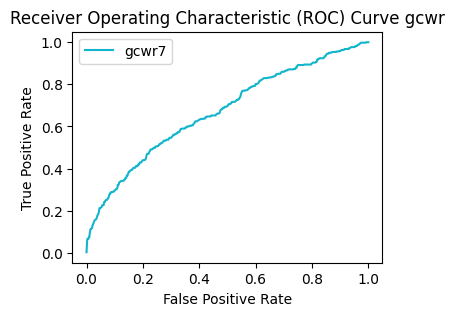

In [24]:
save_line_path_png = data_output_dir_path / "roc" / f"{line_name}.png"

line_width = 1.5
marker_size = 4

# 定义线条颜色的 RGB 变量
valid_color = (18 / 255, 181 / 255, 203 / 255)  # 蓝色
train_color = (249 / 255, 171 / 255, 0 / 255)        # 红色

# 绘制 ROC 曲线
plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, linewidth=line_width, markersize=marker_size, color=valid_color, label=f"{mode_name}{num_epochs}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve {mode_name}')
# plt.grid(True)
plt.savefig(save_line_path_png)  # 请替换为实际的保存路径

# 显示图例
plt.legend()
plt.show()
# num_epochs = 
# = get_mode(mode_name)